# Baseline Performance Evaluation

## Disclaimer: This notebook was constructed with assistance from Gemini 3.1 Pro for code completion, debugging, and graph styling.

## Setup

In [1]:
import csv
import json
import math
import os
import statistics

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

In [2]:
RESULTS_BASE_DIR = "results/selection"
CSV_PATH = "evaluation/baseline_iou_all.csv"
OUTPUT_DIR = "evaluation/baseline"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SCENE_TYPE_MAP = {
    "single/solo":  "Isolated",
    "single/multi": "Clustered",
    "multi":        "Mixed",
}
SCENE_ORDER = ["Isolated", "Clustered", "Mixed"]
EXPECTED_PER_GROUP = 250

COLORS = {
    "Isolated":  "#4878A8",
    "Clustered": "#E8913A",
    "Mixed":     "#59A668",
}

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

## Extract Baseline IoU

In [3]:
all_rows = []
errors = []

for rel_dir, scene_label in SCENE_TYPE_MAP.items():
    group_dir = os.path.join(RESULTS_BASE_DIR, rel_dir)

    if not os.path.isdir(group_dir):
        errors.append(f"MISSING DIRECTORY: {group_dir}")
        continue

    folder_ids = sorted(int(d) for d in os.listdir(group_dir) if d.isdigit())

    if len(folder_ids) != EXPECTED_PER_GROUP:
        errors.append(f"{scene_label}: found {len(folder_ids)} folders, expected {EXPECTED_PER_GROUP}")

    for fid in folder_ids:
        json_path = os.path.join(group_dir, str(fid), "original.json")

        if not os.path.isfile(json_path):
            errors.append(f"MISSING: {json_path}")
            continue

        with open(json_path) as f:
            data = json.load(f)

        try:
            iou = float(data["IoU"])
        except (KeyError, ValueError) as e:
            errors.append(f"BAD IoU in {json_path}: {e}")
            continue

        all_rows.append({
            "scene_type":      scene_label,
            "sample_id":       fid,
            "iou":             iou,
            "num_gt_objects":  len(data.get("ground_truth", {})),
            "image_file":      data.get("image", ""),
            "seed":            data.get("seed", ""),
            "token_count":     data.get("token_count"),
            "raw_token_count": data.get("raw_token_count"),
            "runtime":         data.get("runtime"),
        })

with open(CSV_PATH, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=[
        "scene_type", "sample_id", "iou", "num_gt_objects", "image_file", "seed",
        "token_count", "raw_token_count", "runtime",
    ])
    writer.writeheader()
    writer.writerows(all_rows)

print(f"Wrote {len(all_rows)} rows to {CSV_PATH}")
if errors:
    print(f"\n{len(errors)} issue(s):")
    for e in errors:
        print(f"  - {e}")
else:
    print("No issues.")

Wrote 750 rows to evaluation/baseline_iou_all.csv
No issues.


## Load CSV

In [4]:
rows = []
with open(CSV_PATH) as f:
    for r in csv.DictReader(f):
        rows.append({
            "scene": r["scene_type"],
            "iou": float(r["iou"]),
            "n_gt": int(r["num_gt_objects"]),
            "seed": r["seed"],
        })

groups = {st: [r["iou"] for r in rows if r["scene"] == st] for st in SCENE_ORDER}
all_ious = [r["iou"] for r in rows]

print(f"Loaded {len(rows)} samples")
for st in SCENE_ORDER:
    print(f"  {st}: {len(groups[st])}")

Loaded 750 samples
  Isolated: 250
  Clustered: 250
  Mixed: 250


## Data Integrity

In [5]:
assert len(rows) == 750, f"Expected 750 samples, got {len(rows)}"
assert all(len(groups[st]) == 250 for st in SCENE_ORDER), "Group sizes != 250"
assert set(r["seed"] for r in rows) == {"42669"}, "Inconsistent seeds"
assert sum(1 for r in rows if r["iou"] <= 0.5) == 0, "Found samples with IoU <= 0.5"

print("All checks passed.")

All checks passed.


## Descriptive Statistics

In [6]:
print(f"{'':20s} {'N':>4}  {'Mean':>6}  {'Std':>6}  {'Med':>6}  {'Min':>6}  {'Max':>6}")
print("-" * 68)
for st in SCENE_ORDER:
    v = groups[st]
    print(f"{st:20s} {len(v):>4}  {statistics.mean(v):>6.3f}  {statistics.stdev(v):>6.3f}  "
          f"{statistics.median(v):>6.3f}  {min(v):>6.3f}  {max(v):>6.3f}")
print("-" * 68)
print(f"{'Overall':20s} {len(all_ious):>4}  {statistics.mean(all_ious):>6.3f}  "
      f"{statistics.stdev(all_ious):>6.3f}  {statistics.median(all_ious):>6.3f}  "
      f"{min(all_ious):>6.3f}  {max(all_ious):>6.3f}")

                        N    Mean     Std     Med     Min     Max
--------------------------------------------------------------------
Isolated              250   0.923   0.077   0.947   0.589   0.995
Clustered             250   0.841   0.126   0.893   0.520   0.986
Mixed                 250   0.782   0.134   0.794   0.510   0.985
--------------------------------------------------------------------
Overall               750   0.849   0.129   0.899   0.510   0.995


In [7]:
s = sorted(all_ious)
n = len(s)
print(f"Q25 = {s[n // 4]:.3f}")
print(f"Q75 = {s[3 * n // 4]:.3f}")

Q25 = 0.776
Q75 = 0.951


## IoU Distribution -- Violin Plot

Saved: evaluation/baseline\eval_baseline_iou_distribution.pdf


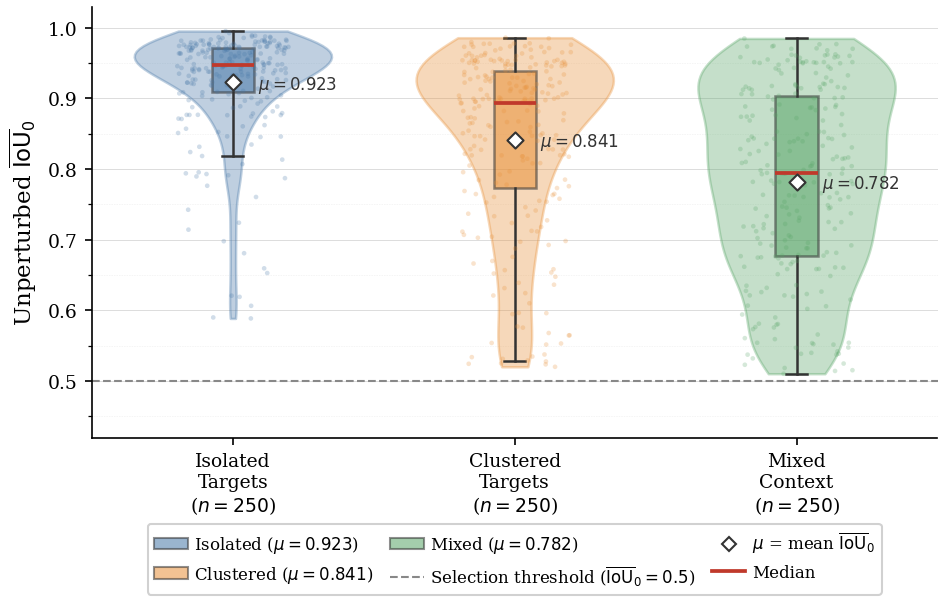

In [8]:
SCENE_LABELS = [
    "Isolated\nTargets\n($n = 250$)",
    "Clustered\nTargets\n($n = 250$)",
    "Mixed\nContext\n($n = 250$)",
]

fig, ax = plt.subplots(figsize=(6.5, 4.2))

positions = [1, 2, 3]
data_arrays = [np.array(groups[st]) for st in SCENE_ORDER]

parts = ax.violinplot(data_arrays, positions=positions,
                      showmeans=False, showmedians=False, showextrema=False, widths=0.7)
for i, body in enumerate(parts["bodies"]):
    c = COLORS[SCENE_ORDER[i]]
    body.set_facecolor(c)
    body.set_edgecolor(c)
    body.set_alpha(0.35)
    body.set_linewidth(1.2)

bp = ax.boxplot(data_arrays, positions=positions, widths=0.15, patch_artist=True,
                showfliers=False, showcaps=True,
                whiskerprops=dict(linewidth=1.2, color="#333"),
                capprops=dict(linewidth=1.2, color="#333"),
                medianprops=dict(linewidth=1.8, color="#C0392B", zorder=5),
                boxprops=dict(linewidth=1.2))
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(COLORS[SCENE_ORDER[i]])
    patch.set_alpha(0.55)
    patch.set_edgecolor("#333")

rng = np.random.default_rng(42)
for i, (arr, pos) in enumerate(zip(data_arrays, positions)):
    jitter = rng.uniform(-0.20, 0.20, size=len(arr))
    ax.scatter(pos + jitter, arr, s=5, alpha=0.25, color=COLORS[SCENE_ORDER[i]],
              edgecolors="none", zorder=2, rasterized=True)

ax.axhline(y=0.5, color="#888", linestyle="--", linewidth=1.0, zorder=1)

for i, (arr, pos) in enumerate(zip(data_arrays, positions)):
    mu = np.mean(arr)
    ax.scatter(pos, mu, marker="D", s=30, color="white",
              edgecolors="#333", linewidths=1.0, zorder=6)
    ax.annotate(f"$\\mu = {mu:.3f}$", xy=(pos, mu), xytext=(12, -1),
               textcoords="offset points", fontsize=8, color="#333", va="center")

ax.set_xticks(positions)
ax.set_xticklabels(SCENE_LABELS, linespacing=1.2)
ax.set_ylabel("Unperturbed $\\overline{\\mathrm{IoU}}_0$")
ax.set_ylim(0.42, 1.03)
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.05))
ax.yaxis.grid(True, which="major", linestyle="-", linewidth=0.4, alpha=0.5)
ax.yaxis.grid(True, which="minor", linestyle=":", linewidth=0.3, alpha=0.3)
ax.set_axisbelow(True)
ax.xaxis.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

legend_elements = [
    Patch(facecolor=COLORS["Isolated"], alpha=0.55, edgecolor="#333",
          label=f'Isolated ($\\mu = {np.mean(data_arrays[0]):.3f}$)'),
    Patch(facecolor=COLORS["Clustered"], alpha=0.55, edgecolor="#333",
          label=f'Clustered ($\\mu = {np.mean(data_arrays[1]):.3f}$)'),
    Patch(facecolor=COLORS["Mixed"], alpha=0.55, edgecolor="#333",
          label=f'Mixed ($\\mu = {np.mean(data_arrays[2]):.3f}$)'),
    Line2D([0], [0], color="#888", linestyle="--", linewidth=1.0,
           label="Selection threshold ($\\overline{\\mathrm{IoU}}_0 = 0.5$)"),
    Line2D([0], [0], marker="D", color="white", markeredgecolor="#333",
           markersize=5, linewidth=0,
           label="$\\mu$ = mean $\\overline{\\mathrm{IoU}}_0$"),
    Line2D([0], [0], color='#C0392B', linestyle='-', linewidth=1.8,
           label='Median'),
]
ax.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, -0.18),
          ncol=3, frameon=True, framealpha=0.9, edgecolor="#ccc",
          fontsize=8, columnspacing=1.0, handletextpad=0.4)

fig.tight_layout()
fig.subplots_adjust(bottom=0.28)

out = os.path.join(OUTPUT_DIR, "eval_baseline_iou_distribution")
fig.savefig(f"{out}.pdf", format="pdf")
fig.savefig(f"{out}.png", format="png")
print(f"Saved: {out}.pdf")
plt.show()

## Per-Group Analysis

In [9]:
for st in SCENE_ORDER:
    v = groups[st]
    above = sum(1 for x in v if x > 0.9)
    below = sum(1 for x in v if x < 0.7)
    print(f"{st}:  above 0.9 -> {above}/250 = {100 * above / 250:.1f}%,  "
          f"below 0.7 -> {below}/250 = {100 * below / 250:.1f}%")

Isolated:  above 0.9 -> 195/250 = 78.0%,  below 0.7 -> 9/250 = 3.6%
Clustered:  above 0.9 -> 107/250 = 42.8%,  below 0.7 -> 39/250 = 15.6%
Mixed:  above 0.9 -> 67/250 = 26.8%,  below 0.7 -> 75/250 = 30.0%


In [10]:
iso = statistics.mean(groups["Isolated"])
clu = statistics.mean(groups["Clustered"])
mix = statistics.mean(groups["Mixed"])
ovr = statistics.mean(all_ious)

print("From full precision:")
print(f"  Isolated - Clustered:  {100 * (iso - clu):.1f} pp")
print(f"  Isolated - Overall:    {100 * (iso - ovr):.1f} pp")
print(f"  Overall - Mixed:       {100 * (ovr - mix):.1f} pp")
print(f"  Isolated - Mixed:      {100 * (iso - mix):.1f} pp")

print("\nFrom table-rounded (3 decimal) values:")
print(f"  Isolated - Clustered:  {100 * (0.923 - 0.841):.1f} pp")
print(f"  Isolated - Overall:    {100 * (0.923 - 0.849):.1f} pp")
print(f"  Overall - Mixed:       {100 * (0.849 - 0.782):.1f} pp")
print(f"  Isolated - Mixed:      {100 * (0.923 - 0.782):.1f} pp")

From full precision:
  Isolated - Clustered:  8.1 pp
  Isolated - Overall:    7.4 pp
  Overall - Mixed:       6.7 pp
  Isolated - Mixed:      14.0 pp

From table-rounded (3 decimal) values:
  Isolated - Clustered:  8.2 pp
  Isolated - Overall:    7.4 pp
  Overall - Mixed:       6.7 pp
  Isolated - Mixed:      14.1 pp


In [11]:
drop = 0.30
print(f"Absolute IoU drop of {drop}:")
print(f"  As % of Isolated mean ({iso:.3f}): {100 * drop / iso:.1f}%")
print(f"  As % of Mixed mean    ({mix:.3f}): {100 * drop / mix:.1f}%")

Absolute IoU drop of 0.3:
  As % of Isolated mean (0.923): 32.5%
  As % of Mixed mean    (0.782): 38.4%


## Scene Complexity Analysis

In [12]:
for st in SCENE_ORDER:
    ngts = [r["n_gt"] for r in rows if r["scene"] == st]
    print(f"{st}:  mean={sum(ngts)/len(ngts):.2f},  "
          f"range=[{min(ngts)}, {max(ngts)}],  median={statistics.median(ngts)}")

Isolated:  mean=1.00,  range=[1, 1],  median=1.0
Clustered:  mean=3.02,  range=[2, 13],  median=2.0
Mixed:  mean=4.06,  range=[2, 22],  median=3.0


In [13]:
def pearson(xs, ys):
    n = len(xs)
    mx, my = sum(xs) / n, sum(ys) / n
    cov = sum((x - mx) * (y - my) for x, y in zip(xs, ys)) / (n - 1)
    sx = math.sqrt(sum((x - mx) ** 2 for x in xs) / (n - 1))
    sy = math.sqrt(sum((y - my) ** 2 for y in ys) / (n - 1))
    return cov / (sx * sy)

for st in ["Mixed", "Clustered"]:
    data = [(r["n_gt"], r["iou"]) for r in rows if r["scene"] == st]
    xs, ys = zip(*data)
    print(f"{st}: r = {pearson(list(xs), list(ys)):.4f}")

print("Isolated: constant n_gt=1, correlation undefined")

Mixed: r = -0.3783
Clustered: r = -0.3461
Isolated: constant n_gt=1, correlation undefined


## Detection Rate Threshold Curve

Saved: evaluation/baseline\eval_baseline_detection_rate_curve.pdf


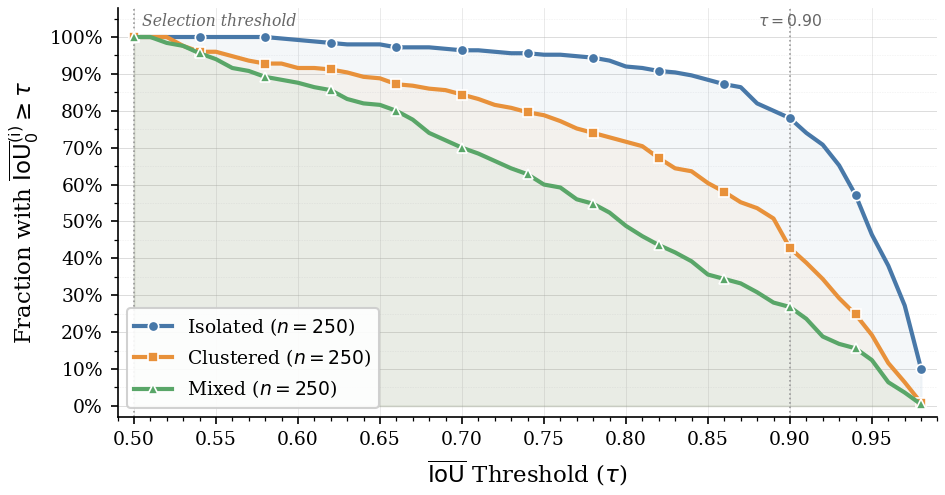

In [14]:
MARKERS = {"Isolated": "o", "Clustered": "s", "Mixed": "^"}
THRESH_MIN, THRESH_MAX, THRESH_STEP = 0.50, 0.98, 0.01

fig, ax = plt.subplots(figsize=(6.5, 3.5))
thresholds = np.arange(THRESH_MIN, THRESH_MAX + THRESH_STEP / 2, THRESH_STEP)
marker_every = max(1, len(thresholds) // 12)

for scene in SCENE_ORDER:
    vals = np.array(groups[scene])
    rates = np.array([np.sum(vals >= t) / len(vals) for t in thresholds])
    ax.plot(thresholds, rates, color=COLORS[scene], linewidth=2.0,
            marker=MARKERS[scene], markersize=5, markevery=marker_every,
            markeredgecolor="white", markeredgewidth=0.8,
            label=f"{scene} ($n = {len(vals)}$)", zorder=3)
    ax.fill_between(thresholds, rates, 0, color=COLORS[scene], alpha=0.06)

for ref_thresh, label_text, h_align in [
    (0.50, "Selection threshold", "left"),
    (0.90, "$\\tau = 0.90$", "center"),
]:
    ax.axvline(x=ref_thresh, color="#999", linestyle=":", linewidth=0.8, zorder=1)
    ax.annotate(label_text,
                xy=(ref_thresh + (0.005 if h_align == "left" else 0), 1.02),
                fontsize=7.5, color="#666", ha=h_align, va="bottom",
                style="italic", annotation_clip=False)

ax.set_xlabel("$\\overline{\\mathrm{IoU}}$ Threshold ($\\tau$)")
ax.set_ylabel("Fraction with $\\overline{\\mathrm{IoU}}_0^{\\mathrm{(i)}} \\geq \\tau$")
ax.set_xlim(THRESH_MIN - 0.01, THRESH_MAX + 0.01)
ax.set_ylim(-0.03, 1.08)
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.05))
ax.xaxis.set_minor_locator(mticker.MultipleLocator(0.01))
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.10))
ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.05))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))
ax.yaxis.grid(True, which="major", linestyle="-", linewidth=0.4, alpha=0.5)
ax.yaxis.grid(True, which="minor", linestyle=":", linewidth=0.3, alpha=0.3)
ax.xaxis.grid(True, which="major", linestyle="-", linewidth=0.4, alpha=0.3)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="lower left", frameon=True, framealpha=0.9, edgecolor="#ccc")

fig.tight_layout()

out = os.path.join(OUTPUT_DIR, "eval_baseline_detection_rate_curve")
fig.savefig(f"{out}.pdf", format="pdf")
fig.savefig(f"{out}.png", format="png")
print(f"Saved: {out}.pdf")
plt.show()

## Detection Rates at Key Thresholds

In [15]:
for tau in [0.50, 0.55, 0.58, 0.78, 0.80, 0.83, 0.84, 0.88, 0.90]:
    rates = {st: sum(1 for v in groups[st] if v >= tau) / 250
             for st in SCENE_ORDER}
    print(f"tau={tau:.2f}:  "
          f"Iso={100 * rates['Isolated']:.1f}%  "
          f"Clu={100 * rates['Clustered']:.1f}%  "
          f"Mix={100 * rates['Mixed']:.1f}%")

tau=0.50:  Iso=100.0%  Clu=100.0%  Mix=100.0%
tau=0.55:  Iso=100.0%  Clu=96.0%  Mix=94.0%
tau=0.58:  Iso=100.0%  Clu=92.8%  Mix=89.2%
tau=0.78:  Iso=94.4%  Clu=74.0%  Mix=54.8%
tau=0.80:  Iso=92.0%  Clu=71.6%  Mix=48.8%
tau=0.83:  Iso=90.4%  Clu=64.4%  Mix=41.6%
tau=0.84:  Iso=89.6%  Clu=63.6%  Mix=39.2%
tau=0.88:  Iso=82.0%  Clu=53.6%  Mix=30.8%
tau=0.90:  Iso=78.0%  Clu=42.8%  Mix=26.8%


In [16]:
print("Isolated -- where does it drop below 90%?")
for tau in np.arange(0.80, 0.90, 0.01):
    rate = sum(1 for v in groups["Isolated"] if v >= tau) / 250
    if 0.85 <= rate <= 0.95:
        print(f"  tau={tau:.2f}: {100*rate:.1f}%")

print("\nMixed -- where does it drop below 90%?")
for tau in np.arange(0.53, 0.63, 0.01):
    rate = sum(1 for v in groups["Mixed"] if v >= tau) / 250
    if 0.85 <= rate <= 0.95:
        print(f"  tau={tau:.2f}: {100*rate:.1f}%")

print("\nMixed -- where does it cross 50%?")
for tau in np.arange(0.77, 0.83, 0.01):
    rate = sum(1 for v in groups["Mixed"] if v >= tau) / 250
    if 0.45 <= rate <= 0.56:
        print(f"  tau={tau:.2f}: {100*rate:.1f}%")

Isolated -- where does it drop below 90%?
  tau=0.80: 92.0%
  tau=0.81: 91.6%
  tau=0.82: 90.8%
  tau=0.83: 90.4%
  tau=0.84: 89.6%
  tau=0.85: 88.4%
  tau=0.86: 87.2%
  tau=0.87: 86.4%

Mixed -- where does it drop below 90%?
  tau=0.55: 94.0%
  tau=0.56: 91.6%
  tau=0.57: 90.8%
  tau=0.58: 89.2%
  tau=0.59: 88.4%
  tau=0.60: 87.6%
  tau=0.61: 86.4%
  tau=0.62: 85.6%

Mixed -- where does it cross 50%?
  tau=0.77: 56.0%
  tau=0.78: 54.8%
  tau=0.79: 52.4%
  tau=0.80: 48.8%
  tau=0.81: 46.0%


## Dataset Metadata

In [17]:
metadata = []
for rel_dir, scene_label in SCENE_TYPE_MAP.items():
    group_dir = os.path.join(RESULTS_BASE_DIR, rel_dir)
    folder_ids = sorted(int(d) for d in os.listdir(group_dir) if d.isdigit())
    for fid in folder_ids:
        with open(os.path.join(group_dir, str(fid), "original.json")) as f:
            data = json.load(f)
        
        gt_labels = [k.rsplit("_", 1)[0] if k.rsplit("_", 1)[-1].isdigit() else k
                     for k in data["ground_truth"]]
        unique_classes = set(gt_labels)
        
        metadata.append({
            "scene":          scene_label,
            "sample_id":      fid,
            "n_gt":           len(data["ground_truth"]),
            "n_classes":      len(unique_classes),
            "classes":        unique_classes,
            "img_w":          data["original_dims"][0],
            "img_h":          data["original_dims"][1],
            "inf_w":          data["inference_dims"][0],
            "inf_h":          data["inference_dims"][1],
            "token_count":    data.get("token_count", None),
            "raw_token_count": data.get("raw_token_count", None),
        })

print(f"Loaded metadata for {len(metadata)} samples")

Loaded metadata for 750 samples


In [18]:
print(f"{'Scene Type':<18} {'Mean':>6} {'Std':>6} {'Med':>5} {'Min':>4} {'Max':>4}")
print("-" * 52)
for st in SCENE_ORDER:
    vals = [m["n_gt"] for m in metadata if m["scene"] == st]
    print(f"{st:<18} {statistics.mean(vals):>6.2f} {statistics.stdev(vals):>6.2f} "
          f"{statistics.median(vals):>5.1f} {min(vals):>4} {max(vals):>4}")

Scene Type           Mean    Std   Med  Min  Max
----------------------------------------------------
Isolated             1.00   0.00   1.0    1    1
Clustered            3.02   1.90   2.0    2   13
Mixed                4.06   2.63   3.0    2   22


In [19]:
print(f"\n{'Scene Type':<18} {'Mean':>6} {'Med':>5} {'Min':>4} {'Max':>4}  (unique classes per image)")
print("-" * 62)
for st in SCENE_ORDER:
    vals = [m["n_classes"] for m in metadata if m["scene"] == st]
    print(f"{st:<18} {statistics.mean(vals):>6.2f} {statistics.median(vals):>5.1f} "
          f"{min(vals):>4} {max(vals):>4}")


Scene Type           Mean   Med  Min  Max  (unique classes per image)
--------------------------------------------------------------
Isolated             1.00   1.0    1    1
Clustered            1.00   1.0    1    1
Mixed                2.57   2.0    2    8


In [20]:
print(f"{'Scene Type':<18} {'Mean W':>7} {'Mean H':>7} {'Min W':>6} {'Max W':>6} {'Min H':>6} {'Max H':>6}")
print("-" * 72)
for st in SCENE_ORDER:
    ws = [m["img_w"] for m in metadata if m["scene"] == st]
    hs = [m["img_h"] for m in metadata if m["scene"] == st]
    print(f"{st:<18} {statistics.mean(ws):>7.0f} {statistics.mean(hs):>7.0f} "
          f"{min(ws):>6} {max(ws):>6} {min(hs):>6} {max(hs):>6}")

downscaled = sum(1 for m in metadata if m["img_w"] != m["inf_w"] or m["img_h"] != m["inf_h"])
print(f"\nDownscaled for inference (max dim > 1024): {downscaled}/{len(metadata)}")

Scene Type          Mean W  Mean H  Min W  Max W  Min H  Max H
------------------------------------------------------------------------
Isolated               494     418    161   1362    190    987
Clustered              502     419    170   1600    142   1200
Mixed                  466     418    199   1024    200    900

Downscaled for inference (max dim > 1024): 5/750


In [21]:
print(f"{'Scene Type':<18} {'Vis. Tokens':>12} {'Raw Tokens':>12} {'Think Tokens':>13}")
print(f"{'':18} {'mean (std)':>12} {'mean (std)':>12} {'mean (std)':>13}")
print("-" * 60)
for st in SCENE_ORDER:
    vis = [m["token_count"] for m in metadata if m["scene"] == st and m["token_count"] is not None]
    raw = [m["raw_token_count"] for m in metadata if m["scene"] == st and m["raw_token_count"] is not None]
    think = [r - v for r, v in zip(raw, vis)]
    if vis:
        print(f"{st:<18} {statistics.mean(vis):>6.0f} ({statistics.stdev(vis):>4.0f}) "
              f"{statistics.mean(raw):>6.0f} ({statistics.stdev(raw):>4.0f}) "
              f"{statistics.mean(think):>7.0f} ({statistics.stdev(think):>4.0f})")
    else:
        print(f"{st:<18}  (no token data)")

Scene Type          Vis. Tokens   Raw Tokens  Think Tokens
                     mean (std)   mean (std)    mean (std)
------------------------------------------------------------
Isolated               41 (  11)     73 (  41)      33 (  40)
Clustered             109 (  74)    450 ( 238)     341 ( 243)
Mixed                 161 ( 122)    734 ( 118)     573 ( 173)


In [22]:
from collections import Counter

label_counts = Counter()
for m in metadata:
    label_counts.update(m["classes"])

print(f"Total unique class labels: {len(label_counts)}\n")
print("Top 20 most frequent:")
for label, count in label_counts.most_common(20):
    print(f"  {label:<30s} {count:>4} images")

print(f"\nBottom 5 (rarest):")
for label, count in label_counts.most_common()[-5:]:
    print(f"  {label:<30s} {count:>4} images")

Total unique class labels: 175

Top 20 most frequent:
  person                          196 images
  dog                             126 images
  bird                            101 images
  table                            35 images
  chair                            29 images
  car                              25 images
  monkey                           23 images
  snake                            21 images
  lizard                           17 images
  cup or mug                       15 images
  watercraft                       15 images
  helmet                           15 images
  flower pot                       12 images
  horse                            11 images
  sunglasses                       11 images
  hat with a wide brim             10 images
  turtle                            9 images
  fox                               9 images
  butterfly                         9 images
  guitar                            9 images

Bottom 5 (rarest):
  ping-pong ball          